# 1 Real GDP across US states

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1

## 1.1 Question 1

### 1.1.1

In [2]:
# US data from FRED

# 1. Connect to FRED
with open('fredapi.txt', 'r') as f:
    fred_api_key = f.read().strip()

from fredapi import Fred

fred = Fred(api_key=fred_api_key)

In [3]:
# 2. Import state codes

from states import STATES

In [4]:
# 3. Download real GDP and population for all states

gdp_data = {}
pop_data = {}

for state in STATES:
    gdp_data[state] = fred.get_series(state + 'RGSP')
    pop_data[state] = fred.get_series(state + 'POP')

# Convert dictionaries to data frames
gdp = pd.DataFrame(gdp_data)
pop = pd.DataFrame(pop_data)

# Change index to year and rename it to 'year'
gdp.index = gdp.index.year
gdp = gdp.rename_axis('year')

pop.index = pop.index.year
pop = pop.rename_axis('year')

# Show data frames
display(gdp.head())
display(pop.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


### 1.1.2

In [5]:
# 4. Keep common years and drop states with missing observations

# Find years available in both data frames
common_years = gdp.index.intersection(pop.index)

# Keep only the common years
gdp_common = gdp.loc[common_years]
pop_common = pop.loc[common_years]

# Find states with no missing observations in either data frame
valid_states = (
    gdp_common.columns[gdp_common.notna().all()]
    .intersection(pop_common.columns[pop_common.notna().all()])
)

# Keep only states with complete observations
gdp_common = gdp_common[valid_states]
pop_common = pop_common[valid_states]


In [6]:
# Count remaining years and states
n_years = len(common_years)
n_states = len(valid_states)

# Identify first and last common year
t_first = common_years.min()
t_last = common_years.max()

# Show results
print(f"Number of years: {n_years}")
print(f"Number of states: {n_states}")
print(f"First year: {t_first}")
print(f"Last year: {t_last}")

Number of years: 29
Number of states: 50
First year: 1997
Last year: 2025


Conclusion: After restricting the data to the common time period and dropping states with missing observations, the final sample contains 50 states and 29 years, covering 1997–2025.

### 1.1.3

In [7]:
# 5. Compute real GDP per person in dollars

y = (gdp_common / pop_common) * 1000

In [8]:
# Show real GDP per person
display(y.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


Real GDP per person is computed as real GDP divided by population, multiplied by 1,000 to account for the difference between millions of dollars and thousands of persons.

### 1.1.4

In [9]:
# 6. Compare real GDP per person in the first and last year

# Select real GDP per person in first and last year
y_first = y.loc[t_first]
y_last = y.loc[t_last]

In [10]:
# Find highest and lowest values and corresponding states
highest_first = y_first.max()
lowest_first = y_first.min()
highest_state_first = y_first.idxmax()
lowest_state_first = y_first.idxmin()

highest_last = y_last.max()
lowest_last = y_last.min()
highest_state_last = y_last.idxmax()
lowest_state_last = y_last.idxmin()

In [11]:
# Compute highest-to-lowest ratio and average across states
ratio_first = highest_first / lowest_first
ratio_last = highest_last / lowest_last

average_first = y_first.mean()
average_last = y_last.mean()

In [12]:
# Show results
print(f"{t_first}:")
print(f"Highest: {highest_state_first}, ${highest_first:,.2f}")
print(f"Lowest: {lowest_state_first}, ${lowest_first:,.2f}")
print(f"Highest/lowest ratio: {ratio_first:.2f}")
print(f"Average: ${average_first:,.2f}")

print()

print(f"{t_last}:")
print(f"Highest: {highest_state_last}, ${highest_last:,.2f}")
print(f"Lowest: {lowest_state_last}, ${lowest_last:,.2f}")
print(f"Highest/lowest ratio: {ratio_last:.2f}")
print(f"Average: ${average_last:,.2f}")

1997:
Highest: DE, $69,748.74
Lowest: ID, $32,062.68
Highest/lowest ratio: 2.18
Average: $44,592.95

2025:
Highest: NY, $94,701.99
Lowest: MS, $42,434.03
Highest/lowest ratio: 2.23
Average: $64,674.46


Conclusion: In 1997, Delaware had the highest real GDP per person ($69,748.74), while Idaho had the lowest ($32,062.68), giving a highest-to-lowest ratio of 2.18. In 2025, New York had the highest ($94,701.99) and Mississippi the lowest ($42,434.03), with a ratio of 2.23. The average real GDP per person increased from $44,592.95 in 1997 to $64,674.46 in 2025. The slightly higher ratio in 2025 indicates that the gap between the highest- and lowest-GDP-per-person states increased slightly over the period.

### 1.1.5

In [13]:
# 7. Prepare data for figures

# Select a handful of states
selected_states = ['CA', 'NY', 'TX', 'MS', 'ID']

# Compute average real GDP per person across states for each year
y_average = y.mean(axis=1)

# Compute GDP per person relative to the average in each year
y_relative = y.div(y_average, axis=0)

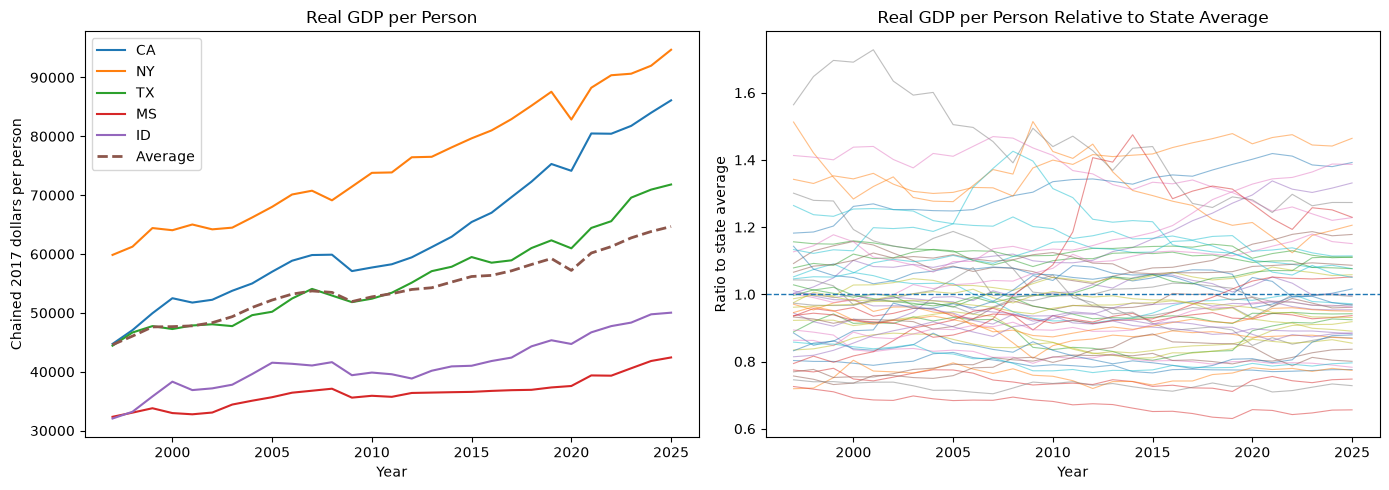

In [14]:
# 8. Plot real GDP per person and relative GDP per person

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel i: Real GDP per person for selected states and state average
for state in selected_states:
    axes[0].plot(y.index, y[state], label=state)

axes[0].plot(y.index, y_average, label='Average', 
             linestyle='--', linewidth=2)

axes[0].set_title('Real GDP per Person')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Chained 2017 dollars per person')
axes[0].legend()

# Panel ii: Real GDP per person relative to state average
for state in y.columns:
    axes[1].plot(y_relative.index, y_relative[state], 
                 alpha=0.5, linewidth=0.8)

axes[1].axhline(1, linestyle='--', linewidth=1)
axes[1].set_title('Real GDP per Person Relative to State Average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ratio to state average')

plt.tight_layout()
plt.show()

Conclusion: The left panel shows the development in real GDP per person for the selected states and the average across all states. New York and California are above the state average in recent years, while Mississippi and Idaho remain below it. The right panel expresses each state's GDP per person relative to the average across all 50 states in the same year, where a value above (below) 1 indicates that the state is above (below) the state average. The right panel shows persistent cross-state differences relative to the annual average, although the relative positions of some states change over time.

## 1.2 Question 2

### 1.2.1

In [15]:
# 9. Compute the standard deviation of log GDP per person across states

log_y = np.log(y)

std_log_y = log_y.std(axis=1)

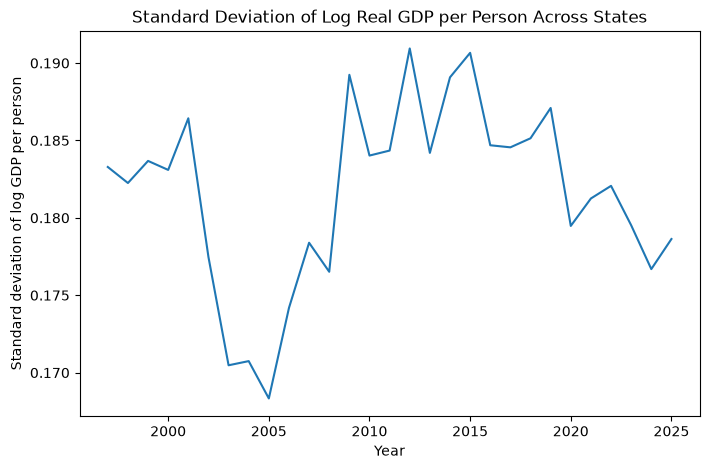

In [16]:
# Plot the standard deviation over time

plt.figure(figsize=(8, 5))
plt.plot(std_log_y.index, std_log_y)

plt.title('Standard Deviation of Log Real GDP per Person Across States')
plt.xlabel('Year')
plt.ylabel('Standard deviation of log GDP per person')

plt.show()

The standard deviation shows how much log real GDP per person differs across states in each year. A higher standard deviation means larger differences between states, while a lower standard deviation means that states are more similar.

### 1.2.2

In [17]:
# 10. Report standard deviation in first and last year

std_first = std_log_y.loc[t_first]
std_last = std_log_y.loc[t_last]

# Find highest and lowest standard deviation
highest_std = std_log_y.max()
highest_std_year = std_log_y.idxmax()

lowest_std = std_log_y.min()
lowest_std_year = std_log_y.idxmin()

# Show results
print(f"Standard deviation in {t_first}: {std_first:.4f}")
print(f"Standard deviation in {t_last}: {std_last:.4f}")
print(f"Highest standard deviation: {highest_std:.4f} in {highest_std_year}")
print(f"Lowest standard deviation: {lowest_std:.4f} in {lowest_std_year}")

Standard deviation in 1997: 0.1833
Standard deviation in 2025: 0.1786
Highest standard deviation: 0.1909 in 2012
Lowest standard deviation: 0.1683 in 2005


Conclusion: The standard deviation of log real GDP per person was 0.1833 in 1997 and 0.1786 in 2025. It reached its highest value of 0.1909 in 2012 and its lowest value of 0.1683 in 2005.

### 1.2.3

Conclusion: The standard deviation fluctuates considerably over the period. It falls until around 2005, indicating convergence across states, but subsequently rises and reaches its highest level in 2012, indicating divergence. These fluctuations may partly reflect that economic shocks, such as the 2008–09 financial crisis, affected states differently due to differences in their economic structure. After 2012, the standard deviation generally declines again. Overall, the standard deviation decreases only slightly from 0.1833 in 1997 to 0.1786 in 2025 and while there is some convergence from the first to the last year, we cannot identify a clear convergence trend over the full period, as the standard deviation fluctuates considerably over time.

## 1.3 Question 3

### 1.3.1

In [18]:
# 11. Compute average annual growth rate for each state

T = t_last - t_first

log_y_first = np.log(y.loc[t_first])
log_y_last = np.log(y.loc[t_last])

g = (log_y_last - log_y_first) / T

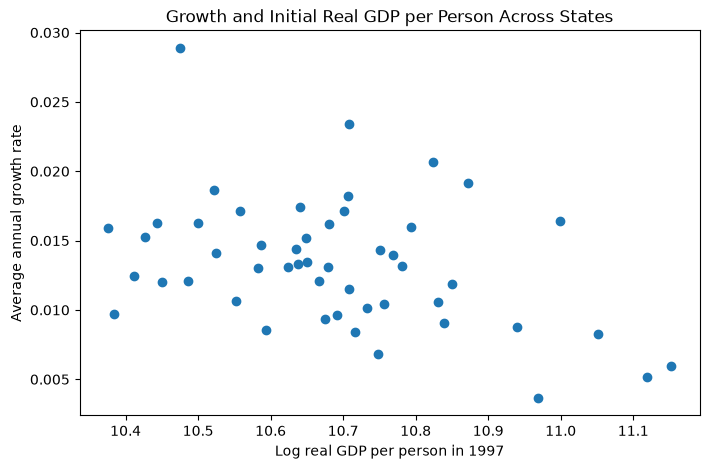

In [19]:
# Plot average annual growth against initial log GDP per person

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

### 1.3.2

In [20]:
# 12. Fit a straight line through the points

b, a = np.polyfit(log_y_first, g, 1)

# Compute correlation
correlation = log_y_first.corr(g)

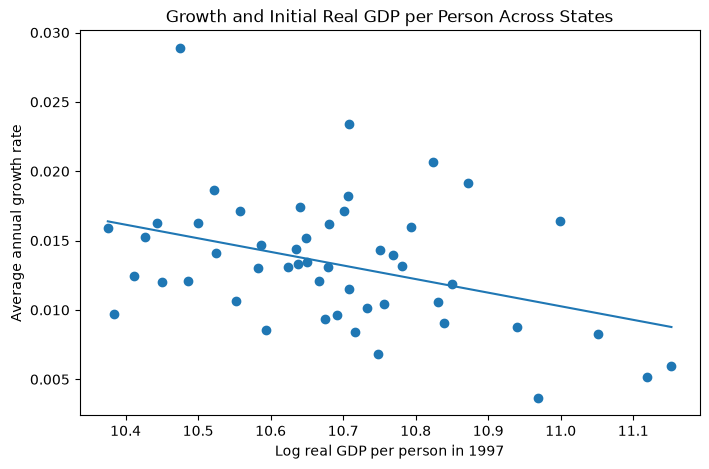

In [21]:
# Plot scatter points and fitted line

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
plt.plot(x_line, a + b * x_line)

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

In [22]:
# Show regression results

print(f"Intercept (a): {a:.4f}")
print(f"Slope (b): {b:.4f}")
print(f"Correlation: {correlation:.4f}")

Intercept (a): 0.1181
Slope (b): -0.0098
Correlation: -0.3886


Conclusion: The estimated slope is \(b=-0.0098\), and the correlation between initial log real GDP per person and subsequent growth is \(-0.3886\). The negative relationship indicates beta convergence: states with lower initial GDP per person tended to grow faster over the period. However, the considerable dispersion around the fitted line suggests that the relationship is not particularly strong.

### 1.3.3

In [23]:
# 13. Identify states with highest and lowest growth rates

highest_growth = g.nlargest(5)
lowest_growth = g.nsmallest(5)

# Show states
print("Five states with highest growth:")
for state, growth in highest_growth.items():
    print(f"{state}: {growth:.4f}")

print("\nFive states with lowest growth:")
for state, growth in lowest_growth.items():
    print(f"{state}: {growth:.4f}")

Five states with highest growth:
ND: 0.0289
CA: 0.0234
WA: 0.0207
MA: 0.0191
SD: 0.0187

Five states with lowest growth:
NV: 0.0037
AK: 0.0052
DE: 0.0059
LA: 0.0068
CT: 0.0083


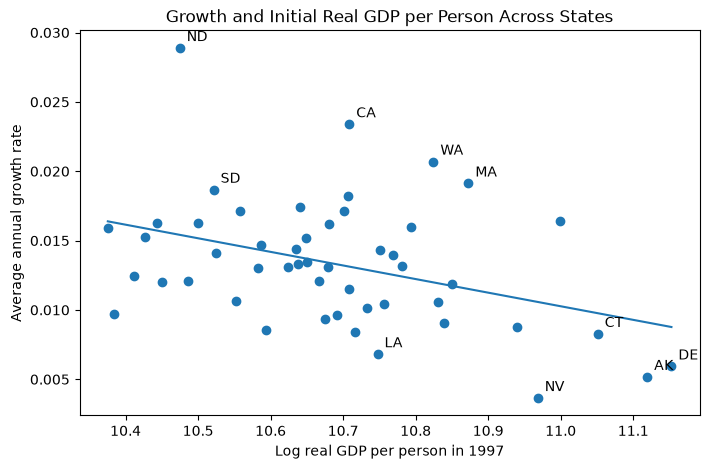

In [24]:
# Plot scatter points, fitted line, and labels

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
plt.plot(x_line, a + b * x_line)

# Add labels for states with highest and lowest growth rates
states_to_label = highest_growth.index.union(lowest_growth.index)

for state in states_to_label:
    plt.annotate(
        state,
        (log_y_first[state], g[state]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

Conclusion: The states with the highest average growth rates are North Dakota, California, Washington, Massachusetts and South Dakota, while Nevada, Alaska, Delaware, Louisiana and Connecticut have the lowest growth rates. The labeled points also illustrate that growth outcomes vary substantially across states, even for states with similar initial GDP per person.

### 1.3.4

In [25]:
# 14. Compute speed of convergence and half-life

T = t_last - t_first

lambda_conv = -np.log(1 + b * T) / T
half_life = np.log(2) / lambda_conv

# Show results
print(f"Speed of convergence (lambda): {lambda_conv:.4f}")
print(f"Half-life (h): {half_life:.2f} years")

Speed of convergence (lambda): 0.0115
Half-life (h): 60.49 years


Conclusion: The estimated annual speed of convergence is 1.15%, meaning that approximately 1.15% of the effect of the initial gap in real GDP per person disappears each year. The corresponding half-life is approximately 60.5 years, meaning that it takes about 60 years for half of an initial gap between states to disappear. This implies that differences in initial real GDP per person disappear relatively slowly over time.

### 1.3.5

Conclusion: The fitted line slopes downward, indicating beta convergence. States with lower initial real GDP per person tended to experience higher subsequent growth. However, the points are relatively dispersed around the fitted line, which is consistent with the moderate negative correlation of -0.3886. The estimated convergence speed of 1.15% per year further suggests that convergence is relatively slow, as only a small part of the initial gap disappears each year. This is also reflected in the estimated half-life of approximately 60.5 years. Thus, while the figure provides evidence of beta convergence, the relationship is not particularly strong and differences in GDP per person across states disappear only gradually over time. Therefore, initial GDP per person is related to subsequent growth, but it does not explain all of the differences in growth rates across states.

This is also consistent with the earlier results in the sense that beta convergence can be present even without a clear downward trend in the overall dispersion of GDP per person across states.

## 1.4 Question 4

### 1.4.1

In [26]:
# 15. Import region information

from states import REGION

In [27]:
# Count the number of states in each region

region_counts = (
    pd.Series(REGION)
    .value_counts()
    .rename_axis('Region')
    .reset_index(name='Number of states')
)

region_counts

,Region,Number of states
0,South,16
1,West,13
2,Midwest,12
3,Northeast,9


In [28]:
# Create a region label for each state

state_regions = pd.Series(REGION).reindex(y.columns)

In [29]:
# Compute average GDP per person within each region

region_average = y.T.groupby(state_regions).mean().T

region_average.head()

,Midwest,Northeast,South,West
year,,,,
1997,43180.798007,48487.699166,42422.062385,45871.955830
1998,44607.752165,50093.105063,44120.203220,46995.539623
1999,45854.585625,51982.553603,45665.857667,48643.607472
2000,46555.188229,52954.139771,44968.040556,48369.835431
2001,46339.288064,53521.899505,45348.431403,48227.726221


In [30]:
# Compute average GDP per person across all states

overall_average = y.mean(axis=1)

display(overall_average.head().to_frame(name='Overall average'))

,Overall average
year,
1997,44592.945851
1998,46059.924764
1999,47622.372595
2000,47670.920524
2001,47806.077913


In [31]:
# Compute regional GDP per person relative to the overall state average

region_relative = region_average.div(overall_average, axis=0)

region_relative.head()

,Midwest,Northeast,South,West
year,,,,
1997,0.968332,1.087340,0.951318,1.028682
1998,0.968472,1.087564,0.957887,1.020313
1999,0.962879,1.091557,0.958916,1.021444
2000,0.976595,1.110827,0.943301,1.014661
2001,0.969318,1.119563,0.948591,1.008820


Conclusion: The four regions contain 9 states in the Northeast, 12 in the Midwest, 16 in the South, and 13 in the West. For each year, regional average real GDP per person is divided by the average across all states. A value above 1 therefore indicates that a region has higher average real GDP per person than the overall state average, while a value below 1 indicates a lower average.

### 1.4.2

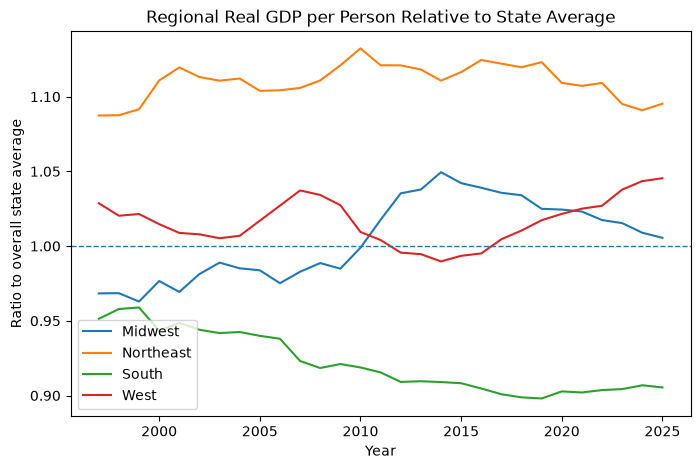

In [32]:
# 16. Plot regional GDP per person relative to the overall average

plt.figure(figsize=(8, 5))

for region in region_relative.columns:
    plt.plot(region_relative.index, region_relative[region], label=region)

plt.axhline(1, linestyle='--', linewidth=1)

plt.xlabel('Year')
plt.ylabel('Ratio to overall state average')
plt.title('Regional Real GDP per Person Relative to State Average')
plt.legend()

plt.show()

Conclusion: The figure shows clear differences in relative real GDP per person across the four regions. The Northeast remains above the overall state average throughout the period, while the South remains below it. The Midwest moves from below to slightly above the overall average, while the West fluctuates around the overall average.

### 1.4.3

In [37]:
# 17. Get regional values in the first and last year

first_values = region_relative.loc[t_first]
last_values = region_relative.loc[t_last]

In [34]:
# Compute the change between the first and last year

change = last_values - first_values

In [35]:
# Combine first year, last year, and change in one table

regional_changes = pd.DataFrame({
    'First year': first_values,
    'Last year': last_values,
    'Change': change
})

regional_changes

,First year,Last year,Change
Midwest,0.968332,1.005527,0.037194
Northeast,1.087340,1.095232,0.007892
South,0.951318,0.905418,-0.045900
West,1.028682,1.045378,0.016696


In [36]:
# Identify the region with the largest absolute change

largest_move_region = change.abs().idxmax()
largest_move = change[largest_move_region]

print(f"Region with largest change: {largest_move_region}")
print(f"Change: {largest_move:.4f}")

Region with largest change: South
Change: -0.0459


Conclusion: Between the first and last year, the Midwest increases from 0.9683 to 1.0055, the Northeast from 1.0873 to 1.0952, and the West from 1.0287 to 1.0454. These positive changes indicate that the regions have increased their real GDP per person relative to the overall state average. In contrast, the South decreases from 0.9513 to 0.9054, indicating that its real GDP per person has fallen further relative to the overall state average. The South therefore experiences the largest absolute change, with a decrease of approximately 0.0459. 
Thus, the South moves the most over the period, and the movement is downward relative to the overall state average.